# Feature Engineering

In [1473]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler
from category_encoders import TargetEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant


In [1474]:
def zero_pct(df, cols):
    """Share of zero values per column, sorted descending."""
    return (df[cols] == 0).mean().to_frame("ZERO_PCT").sort_values("ZERO_PCT", ascending=False)

In [1475]:
# PATH DEFINITIONS
BASE_DIR = Path().resolve().parent

DATA_DIR = BASE_DIR / "data"
CLEAN_DATA_DIR = DATA_DIR / "data_clean"

In [1476]:
# TODO: revisit this read approach — see cleaning.py for a cleaner pattern
df_clean = pd.read_csv(CLEAN_DATA_DIR / "train_clean.csv", keep_default_na=False, na_values=[""])

# Classification and Overview

In [1477]:
df_clean.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE,HASGARAGE,HASPOOL
0,1,60,RL,65.0,8450.0,PAVE,NA,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706.0,UNF,0.0,150.0,856.0,GASA,EX,Y,SBRKR,856.0,854.0,0.0,1710.0,1,0,2,1,3,1,GD,8,TYP,0,NA,ATTCHD,RFN,2,548.0,TA,TA,Y,0.0,61.0,0.0,0.0,0.0,NA,NA,0,2,2008,WD,NORMAL,208500.0,True,False
1,2,20,RL,80.0,9600.0,PAVE,NA,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,None,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978.0,UNF,0.0,284.0,1262.0,GASA,EX,Y,SBRKR,1262.0,0.0,0.0,1262.0,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,RFN,2,460.0,TA,TA,Y,298.0,0.0,0.0,0.0,0.0,NA,NA,0,5,2007,WD,NORMAL,181500.0,True,False
2,3,60,RL,68.0,11250.0,PAVE,NA,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486.0,UNF,0.0,434.0,920.0,GASA,EX,Y,SBRKR,920.0,866.0,0.0,1786.0,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,RFN,2,608.0,TA,TA,Y,0.0,42.0,0.0,0.0,0.0,NA,NA,0,9,2008,WD,NORMAL,223500.0,True,False
3,4,70,RL,60.0,9550.0,PAVE,NA,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,None,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216.0,UNF,0.0,540.0,756.0,GASA,GD,Y,SBRKR,961.0,756.0,0.0,1717.0,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,UNF,3,642.0,TA,TA,Y,0.0,35.0,272.0,0.0,0.0,NA,NA,0,2,2006,WD,ABNORML,140000.0,True,False
4,5,60,RL,84.0,14260.0,PAVE,NA,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655.0,UNF,0.0,490.0,1145.0,GASA,EX,Y,SBRKR,1145.0,1053.0,0.0,2198.0,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,RFN,3,836.0,TA,TA,Y,192.0,84.0,0.0,0.0,0.0,NA,NA,0,12,2008,WD,NORMAL,250000.0,True,False


In [1478]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1412 non-null   int64  
 1   MSSUBCLASS     1412 non-null   int64  
 2   MSZONING       1412 non-null   str    
 3   LOTFRONTAGE    1412 non-null   float64
 4   LOTAREA        1412 non-null   float64
 5   STREET         1412 non-null   str    
 6   ALLEY          1412 non-null   str    
 7   LOTSHAPE       1412 non-null   str    
 8   LANDCONTOUR    1412 non-null   str    
 9   UTILITIES      1412 non-null   str    
 10  LOTCONFIG      1412 non-null   str    
 11  LANDSLOPE      1412 non-null   str    
 12  NEIGHBORHOOD   1412 non-null   str    
 13  CONDITION1     1412 non-null   str    
 14  CONDITION2     1412 non-null   str    
 15  BLDGTYPE       1412 non-null   str    
 16  HOUSESTYLE     1412 non-null   str    
 17  OVERALLQUAL    1412 non-null   int64  
 18  OVERALLCOND    1412

In [1479]:
ord_cols = [
    "LOTSHAPE", "UTILITIES", "LANDSLOPE", "OVERALLQUAL",
    "OVERALLCOND", "EXTERQUAL", "EXTERCOND", "BSMTQUAL",
    "BSMTCOND", "BSMTEXPOSURE", "BSMTFINTYPE1", "BSMTFINTYPE2",
    "HEATINGQC", "ELECTRICAL", "KITCHENQUAL", "FUNCTIONAL",
    "FIREPLACEQU", "GARAGEFINISH", "GARAGEQUAL", "GARAGECOND",
    "PAVEDDRIVE", "FENCE"
]

nom_cols = [
    "MSSUBCLASS", "MSZONING", "STREET", "ALLEY", "LANDCONTOUR",
    "LOTCONFIG", "NEIGHBORHOOD", "CONDITION1", "CONDITION2",
    "BLDGTYPE", "HOUSESTYLE", "ROOFSTYLE", "ROOFMATL",
    "EXTERIOR1ST", "EXTERIOR2ND", "MASVNRTYPE", "FOUNDATION",
    "HEATING", "CENTRALAIR", "GARAGETYPE", "MISCFEATURE",
    "SALETYPE", "SALECONDITION"
]


disc_cols = df_clean.select_dtypes(include='int64').drop(
    columns=["ID"] + ord_cols + nom_cols, errors="ignore"
)

# SALEPRICE is the target, not a feature: kept out of cont_cols so it never
# gets swept into the generic feature-treatment loops below (see target
# transformation cell in the Quantitative Continuous section).
cont_cols = list(df_clean.select_dtypes(include='float64').drop(columns=["SALEPRICE"], errors="ignore").columns)
bool_cols = list(df_clean.select_dtypes(include='bool').columns)


# Qualitative ordinal

In [1480]:
df_ord = df_clean.copy()

for col in ord_cols:
    print(df_ord[col].value_counts().sort_index(ascending=False))
    print()

LOTSHAPE
REG    886
IR3     10
IR2     40
IR1    476
Name: count, dtype: int64

UTILITIES
NOSEWA       1
ALLPUB    1411
Name: count, dtype: int64

LANDSLOPE
SEV      13
MOD      64
GTL    1335
Name: count, dtype: int64

OVERALLQUAL
10     17
9      43
8     166
7     313
6     371
5     381
4     103
3      14
2       3
1       1
Name: count, dtype: int64

OVERALLCOND
9     22
8     72
7    200
6    248
5    792
4     52
3     20
2      5
1      1
Name: count, dtype: int64

EXTERQUAL
TA    871
GD    478
FA     12
EX     51
Name: count, dtype: int64

EXTERCOND
TA    1239
PO       1
GD     145
FA      24
EX       3
Name: count, dtype: int64

BSMTQUAL
TA    648
GD    609
FA     35
EX    120
Name: count, dtype: int64

BSMTCOND
TA    1301
PO       2
GD      64
FA      45
Name: count, dtype: int64

BSMTEXPOSURE
NO    944
MN    114
GD    133
AV    221
Name: count, dtype: int64

BSMTFINTYPE1
UNF    426
REC    132
LWQ     74
GLQ    412
BLQ    148
ALQ    220
Name: count, dtype: int64

BSMTFINTYP

In [1481]:
drop_cols = ["UTILITIES"]
add_cols = []

# GRADES 1-10
grade_map = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: 2,
    8: 3,
    9: 3,
    10: 3,
}
df_ord["OVERALLCOND"] = df_ord["OVERALLCOND"].map(grade_map)
df_ord["OVERALLQUAL"] = df_ord["OVERALLQUAL"].map(grade_map)

# FIVE QUALITIES
qual5_map = {
    "NA": 0,
    "PO": 0,
    "FA": 2,
    "TA": 2,
    "GD": 3,
    "EX": 3,
}
df_ord["EXTERQUAL"] = df_ord["EXTERQUAL"].map(qual5_map)
df_ord["EXTERCOND"] = df_ord["EXTERCOND"].map(qual5_map)
df_ord["HEATINGQC"] = df_ord["HEATINGQC"].map(qual5_map)
df_ord["KITCHENQUAL"] = df_ord["KITCHENQUAL"].map(qual5_map)

# SIX QUALITIES
qual6_map = {"NA": 0, "PO": 0, "FA": 2, "TA": 2, "GD": 3, "EX": 3}

df_ord["BSMTQUAL"] = df_ord["BSMTQUAL"].map(qual6_map)
df_ord["BSMTCOND"] = df_ord["BSMTCOND"].map(qual6_map)
df_ord["FIREPLACEQU"] = df_ord["FIREPLACEQU"].map(qual6_map)
df_ord["GARAGEQUAL"] = df_ord["GARAGEQUAL"].map(qual6_map)
df_ord["GARAGECOND"] = df_ord["GARAGECOND"].map(qual6_map)

# BSMT TYPE
bsmt_fin_map = {
    "NA": 0,
    "UNF": 1,
    "LWQ": 2,
    "REC": 2,
    "BLQ": 2,
    "ALQ": 3,
    "GLQ": 3,
}
df_ord["BSMTFINTYPE1"] = df_ord["BSMTFINTYPE1"].map(bsmt_fin_map)
df_ord["BSMTFINTYPE2"] = df_ord["BSMTFINTYPE2"].map(bsmt_fin_map)

# SPECIAL CASES
df_ord["LANDSLOPE"] = df_ord["LANDSLOPE"].map(
    {"NA": 0, "SEV": 3, "MOD": 2, "GTL": 1}
)
df_ord["BSMTEXPOSURE"] = df_ord["BSMTEXPOSURE"].map(
    {"NA": 0, "NO": 1, "MN": 1, "AV": 1, "GD": 2}
)
df_ord["GARAGEFINISH"] = df_ord["GARAGEFINISH"].map(
    {"NA": 0, "UNF": 1, "RFN": 2, "FIN": 3}
)

df_ord["ELECTRICAL"] = df_ord["ELECTRICAL"].map(
    {"MIX": 1, "FUSEP": 1, "FUSEF": 2, "FUSEA": 2, "SBRKR": 3}
)

df_ord["FENCE"] = df_ord["FENCE"].map(
    {"NA": 0, "MNWW": 1, "GDWO": 1, "MNPRV": 1, "GDPRV": 1}
)

df_ord["FUNCTIONAL"] = df_ord["FUNCTIONAL"].map(
    {
        "SEV": 0,
        "MAJ2": 0,
        "MAJ1": 0,
        "MOD": 1,
        "MIN2": 1,
        "MIN1": 1,
        "TYP": 2,
        "NA": 0,
    }
)

# BOOLEAN CONVERSION
df_ord = df_ord.rename(columns={"FENCE": "HASFENCE"})
df_ord["HASFENCE"] = df_ord["HASFENCE"].astype("bool")
drop_cols.append("FENCE")
add_cols.append("HASFENCE")

df_ord["PAVEDDRIVE"] = df_ord["PAVEDDRIVE"].map(
    {"NA": 0, "MNWW": 1, "GDWO": 1, "MNPRV": 1, "GDPRV": 1}
)
df_ord = df_ord.rename(columns={"PAVEDDRIVE": "HASPAVEDDRIVE"})
df_ord["HASPAVEDDRIVE"] = df_ord["HASPAVEDDRIVE"].astype("bool")
drop_cols.append("PAVEDDRIVE")
add_cols.append("HASPAVEDDRIVE")


df_ord["LOTSHAPE"] = df_ord["LOTSHAPE"].map(
    {"REG": 1, "IR1": 0, "IR2": 0, "IR3": 0}
)
df_ord = df_ord.rename(columns={"LOTSHAPE": "HASREGULARLOTSHAPE"})
df_ord["HASREGULARLOTSHAPE"] = df_ord["HASREGULARLOTSHAPE"].astype("bool")
drop_cols.append("LOTSHAPE")
add_cols.append("HASREGULARLOTSHAPE")

# UPDATE ORD_COLS
ord_cols = list(set(ord_cols) - set(drop_cols))
bool_cols = list(set(bool_cols).union(set(add_cols)))

In [1482]:
for col in ord_cols:
    print(df_ord[col].value_counts().sort_index(ascending=False))
    print()

FIREPLACEQU
3    396
2    340
0    676
Name: count, dtype: int64

GARAGEFINISH
3    345
2    413
1    580
0     74
Name: count, dtype: int64

FUNCTIONAL
2    1322
1      71
0      19
Name: count, dtype: int64

LANDSLOPE
3      13
2      64
1    1335
Name: count, dtype: int64

EXTERCOND
3     148
2    1263
0       1
Name: count, dtype: int64

HEATINGQC
3    959
2    452
0      1
Name: count, dtype: int64

BSMTFINTYPE2
3      33
2     133
1    1246
Name: count, dtype: int64

BSMTCOND
3      64
2    1346
0       2
Name: count, dtype: int64

BSMTFINTYPE1
3    632
2    354
1    426
Name: count, dtype: int64

GARAGECOND
3      11
2    1320
0      81
Name: count, dtype: int64

OVERALLQUAL
3     226
2    1065
1     121
Name: count, dtype: int64

EXTERQUAL
3    529
2    883
Name: count, dtype: int64

KITCHENQUAL
3    672
2    740
Name: count, dtype: int64

ELECTRICAL
3    1300
2     109
1       3
Name: count, dtype: int64

BSMTQUAL
3    729
2    683
Name: count, dtype: int64

OVERALLCOND
3     

In [1483]:
pd.set_option('display.max_columns', None)
df_ord.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,HASREGULARLOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,HASPAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,HASFENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE,HASGARAGE,HASPOOL
0,1,60,RL,65.0,8450.0,PAVE,NA,True,LVL,ALLPUB,INSIDE,1,COLLGCR,NORM,NORM,1FAM,2STORY,2,2,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,3,2,PCONC,3,2,1,3,706.0,1,0.0,150.0,856.0,GASA,3,Y,3,856.0,854.0,0.0,1710.0,1,0,2,1,3,1,3,8,2,0,0,ATTCHD,2,2,548.0,2,2,True,0.0,61.0,0.0,0.0,0.0,False,NA,0,2,2008,WD,NORMAL,208500.0,True,False
1,2,20,RL,80.0,9600.0,PAVE,NA,True,LVL,ALLPUB,FR2,1,VEENKER,FEEDR,NORM,1FAM,1STORY,2,3,1976,1976,GABLE,COMPSHG,METALSD,METALSD,None,0.0,2,2,CBLOCK,3,2,2,3,978.0,1,0.0,284.0,1262.0,GASA,3,Y,3,1262.0,0.0,0.0,1262.0,0,1,2,0,3,1,2,6,2,1,2,ATTCHD,2,2,460.0,2,2,True,298.0,0.0,0.0,0.0,0.0,False,NA,0,5,2007,WD,NORMAL,181500.0,True,False
2,3,60,RL,68.0,11250.0,PAVE,NA,False,LVL,ALLPUB,INSIDE,1,COLLGCR,NORM,NORM,1FAM,2STORY,2,2,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,3,2,PCONC,3,2,1,3,486.0,1,0.0,434.0,920.0,GASA,3,Y,3,920.0,866.0,0.0,1786.0,1,0,2,1,3,1,3,6,2,1,2,ATTCHD,2,2,608.0,2,2,True,0.0,42.0,0.0,0.0,0.0,False,NA,0,9,2008,WD,NORMAL,223500.0,True,False
3,4,70,RL,60.0,9550.0,PAVE,NA,False,LVL,ALLPUB,CORNER,1,CRAWFOR,NORM,NORM,1FAM,2STORY,2,2,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,None,0.0,2,2,BRKTIL,2,3,1,3,216.0,1,0.0,540.0,756.0,GASA,3,Y,3,961.0,756.0,0.0,1717.0,1,0,1,0,3,1,3,7,2,1,3,DETCHD,1,3,642.0,2,2,True,0.0,35.0,272.0,0.0,0.0,False,NA,0,2,2006,WD,ABNORML,140000.0,True,False
4,5,60,RL,84.0,14260.0,PAVE,NA,False,LVL,ALLPUB,FR2,1,NORIDGE,NORM,NORM,1FAM,2STORY,3,2,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,3,2,PCONC,3,2,1,3,655.0,1,0.0,490.0,1145.0,GASA,3,Y,3,1145.0,1053.0,0.0,2198.0,1,0,2,1,4,1,3,9,2,1,2,ATTCHD,2,3,836.0,2,2,True,192.0,84.0,0.0,0.0,0.0,False,NA,0,12,2008,WD,NORMAL,250000.0,True,False


# Quantitative Continuous

In [1484]:
df_cont = df_ord.copy()

## Skewness Analysis and Transformation

In [1485]:
skew_df = df_cont[cont_cols].skew().to_frame("SKEWNESS").sort_values("SKEWNESS", ascending=False)
skew_df

,SKEWNESS
LOTAREA,12.119696
3SSNPORCH,10.379001
LOWQUALFINSF,8.866842
BSMTFINSF2,4.198216
SCREENPORCH,4.042645
ENCLOSEDPORCH,3.104135
MASVNRAREA,2.653450
OPENPORCHSF,2.367689
TOTALBSMTSF,2.163751
BSMTFINSF1,1.696633


In [1486]:
sym_cols = skew_df[skew_df["SKEWNESS"].abs() < 0.5].index
mod_skew_cols = skew_df[skew_df["SKEWNESS"].abs().between(0.5, 1.0)].index
high_skew_cols = skew_df[skew_df["SKEWNESS"].abs() > 1.0].index


#### High skew treatment

In [1487]:
zero_heavy_cols = [
    "3SSNPORCH",
    "LOWQUALFINSF",
    "BSMTFINSF2",
    "SCREENPORCH",
    "ENCLOSEDPORCH",
    "MASVNRAREA",
    "OPENPORCHSF",
    "BSMTFINSF1",
    "WOODDECKSF",
]

high_skew_cols = list(set(high_skew_cols) - set(zero_heavy_cols))


#### Zero Presence Analysis (Zero-Heavy High-Skew Variables)

In [1488]:
zero_df = zero_pct(df_cont, zero_heavy_cols)
zero_df

,ZERO_PCT
3SSNPORCH,0.983711
LOWQUALFINSF,0.982295
SCREENPORCH,0.917847
BSMTFINSF2,0.882436
ENCLOSEDPORCH,0.856232
MASVNRAREA,0.586402
WOODDECKSF,0.512040
OPENPORCHSF,0.441218
BSMTFINSF1,0.301700


#### Power Transformation (High Skew Variables)

In [1489]:
pt_map = {}

for col in high_skew_cols:
    pt = PowerTransformer()
    df_cont[col + "_TRANSFORMED"] = pt.fit_transform(df_cont[[col]])[:, 0]
    pt_map[col] = pt


pt_cols = [c for c in df_cont.columns if "_TRANSFORMED" in c]

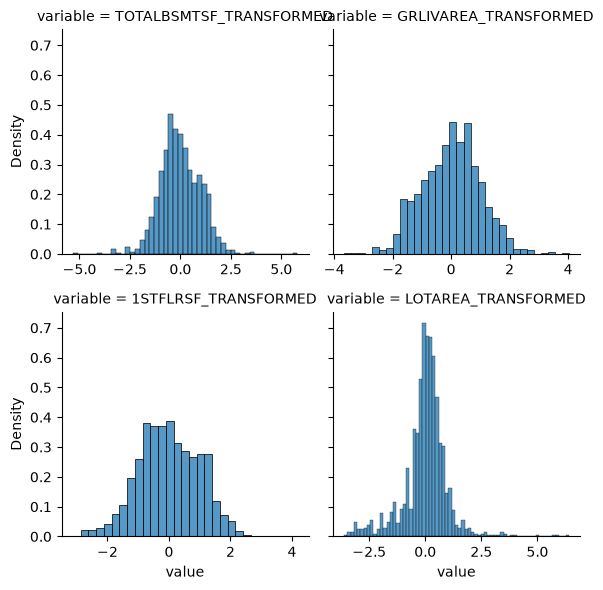

In [1490]:
sns.FacetGrid(
    pd.melt(df_cont, value_vars=pt_cols),
    col="variable",
    col_wrap=2,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value", stat="density")

#### Zero-Heavy Variables → Boolean Flags

In [1491]:
drop_cols = []
add_cols = []

ZERO_PCT_THRESH = 70

zero_flag_map = {
    col: "HAS" + col
    for col in zero_df[zero_df["ZERO_PCT"] > ZERO_PCT_THRESH].index
}

for old_col, new_col in zero_flag_map.items():
    df_cont = df_cont.rename(columns={old_col: new_col})
    df_cont[new_col] = np.where(df_cont[new_col] == 0, 0, 1).astype("bool")
    drop_cols.append(old_col)
    add_cols.append(new_col)


zero_heavy_cols = list(set(zero_heavy_cols) - set(drop_cols))
cont_cols = list(set(cont_cols) - set(drop_cols))
bool_cols = list(set(bool_cols).union(set(add_cols)))

#### Remaining Skewed Variables → Log Transform + Presence Flag

In [1492]:
# HANDLE REMAINING VARIABLES (moderate zero presence: bool flag + log1p)
log_flag_map = {col: "HAS" + col for col in zero_heavy_cols}

for old_col, new_col in log_flag_map.items():
    df_cont[new_col] = np.where(df_cont[old_col] == 0, 0, 1).astype("bool")
    df_cont[old_col + "_LOG"] = np.log1p(df_cont[old_col])
    add_cols.append(new_col)

log_cols = [c for c in df_cont.columns if "_LOG" in c]
bool_cols = list(set(bool_cols).union(set(add_cols)))

log_cols

['LOWQUALFINSF_LOG',
 'OPENPORCHSF_LOG',
 'MASVNRAREA_LOG',
 'BSMTFINSF1_LOG',
 'BSMTFINSF2_LOG',
 'WOODDECKSF_LOG',
 'ENCLOSEDPORCH_LOG',
 '3SSNPORCH_LOG',
 'SCREENPORCH_LOG']

#### Summary: High skew treated Columns

In [1493]:
high_skew_final = list(set(pt_cols).union(set(log_cols)))

### Moderate Skew

In [1494]:
zero_df = zero_pct(df_cont, mod_skew_cols)
zero_df.round(2)

,ZERO_PCT
2NDFLRSF,0.56
BSMTUNFSF,0.06


In [1495]:
add_cols = []

df_cont["HAS2NDFLRSF"] = np.where(df_cont["2NDFLRSF"] == 0, 0, 1).astype("bool")

df_cont["2NDFLRSF_LOG"] = np.log1p(df_cont["2NDFLRSF"])
add_cols.append("HAS2NDFLRSF")

bool_cols = list(set(bool_cols).union(set(add_cols)))

In [1496]:
bsmt_unf_pt = PowerTransformer()
df_cont["BSMTUNFSF_TRANSFORMED"] = bsmt_unf_pt.fit_transform(df_cont[['BSMTUNFSF']])[:, 0]

#### Summary: Moderate skew treated Columns

In [1497]:
log_cols = ['2NDFLRSF_LOG']
pt_cols = ['BSMTUNFSF_TRANSFORMED']
mod_skew_final = list(set(pt_cols).union(set(log_cols)))

### Approximately Symmetric Treatment

In [1498]:
zero_df = zero_pct(df_cont, sym_cols)
zero_df.round(2)

,ZERO_PCT
LOTFRONTAGE,0.18
GARAGEAREA,0.05


In [1499]:
sym_final = []
add_cols = []

scaler = StandardScaler()
df_cont['GARAGEAREA_SCALED'] = scaler.fit_transform(df_cont[['GARAGEAREA']])[:, 0]
sym_final.append('GARAGEAREA_SCALED')


df_cont["LOTFRONTAGE_LOG"] = np.log1p(df_cont["LOTFRONTAGE"])
sym_final.append("LOTFRONTAGE_LOG")

df_cont["HASLOTFRONTAGE"] = np.where(df_cont["LOTFRONTAGE"] == 0, 0, 1).astype("bool")
add_cols.append("HASLOTFRONTAGE")
bool_cols = list(set(bool_cols).union(set(add_cols)))

In [1500]:
cont_cols = sym_final

cont_cols = list(set(cont_cols).union(set(mod_skew_final)))
cont_cols = list(set(cont_cols).union(set(high_skew_final)))

### Target Variable (SALEPRICE) — Transformed Separately from Features

In [1501]:
price_pt = PowerTransformer()
df_cont["SALEPRICE_TRANSFORMED"] = price_pt.fit_transform(df_cont[["SALEPRICE"]])

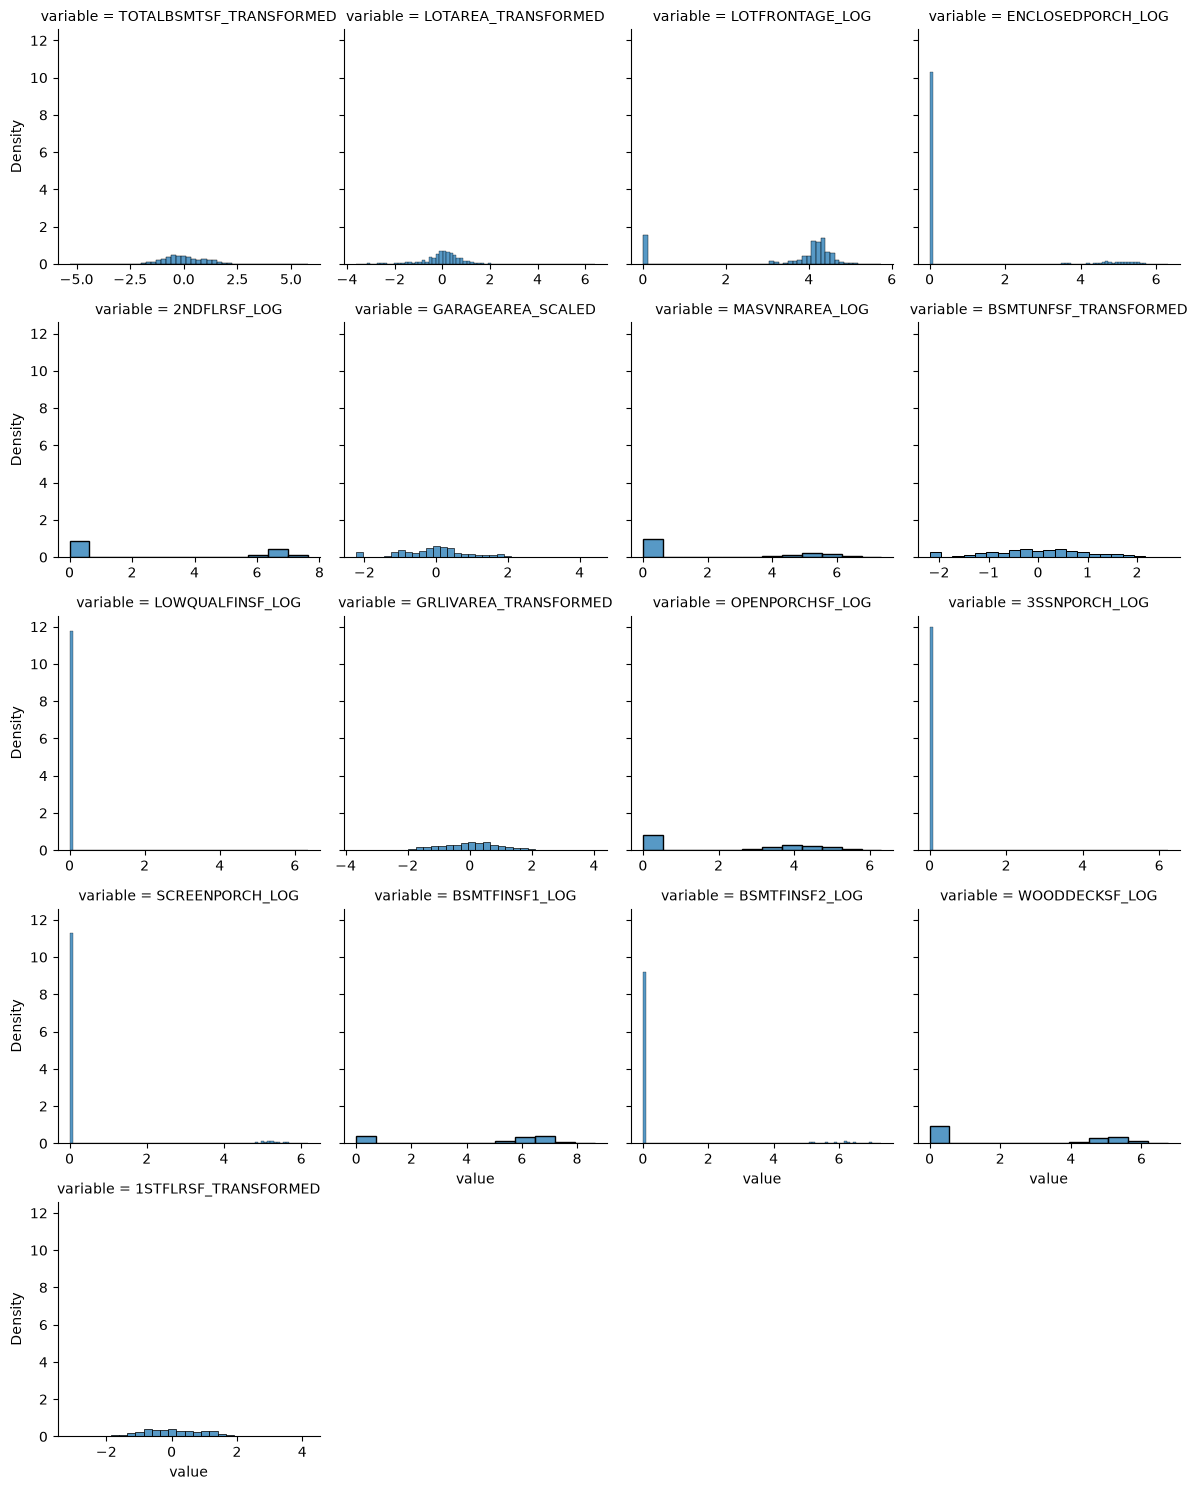

In [1502]:
sns.FacetGrid(
    pd.melt(df_cont, value_vars=cont_cols),
    col="variable",
    col_wrap=4,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value", stat="density")

## Outlier treatment

In [1503]:
zero_df = zero_pct(df_cont, cont_cols)
zero_df = zero_df[zero_df['ZERO_PCT'] > 0]

zero_df

,ZERO_PCT
3SSNPORCH_LOG,0.983711
LOWQUALFINSF_LOG,0.982295
SCREENPORCH_LOG,0.917847
BSMTFINSF2_LOG,0.882436
ENCLOSEDPORCH_LOG,0.856232
MASVNRAREA_LOG,0.586402
2NDFLRSF_LOG,0.563739
WOODDECKSF_LOG,0.512040
OPENPORCHSF_LOG,0.441218
BSMTFINSF1_LOG,0.301700


In [1504]:
zero_heavy_final_cols = zero_df.index
outlier_cols = list(set(cont_cols) - set(zero_heavy_final_cols))

In [1505]:
df_out = df_cont.copy()

for col in outlier_cols:

    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outliers = (df_out[col] < lower_bound) | (df_out[col] > upper_bound)

    df_out = df_out[~mask_outliers]


pct_removed = round((df_cont.shape[0] - df_out.shape[0]) / df_cont.shape[0] * 100, 2)
print(f"{pct_removed}% removed")

df_cont = df_out.copy()
df_cont.shape[0]

11.69% removed


1247

In [1506]:
df_out = df_cont.copy()

for col in zero_heavy_final_cols:

    non_zero_values = df_cont.loc[df_cont[col] > 0, col]

    Q1 = non_zero_values.quantile(0.25)
    Q3 = non_zero_values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outliers = (df_out[col] == 0) | ((df_out[col] > lower_bound) & (df_out[col] < upper_bound))

pct_removed = round((df_cont.shape[0] - df_out.shape[0]) / df_cont.shape[0] * 100, 2)
print(f"{pct_removed}% removed")
df_cont.shape[0]

0.0% removed


1247

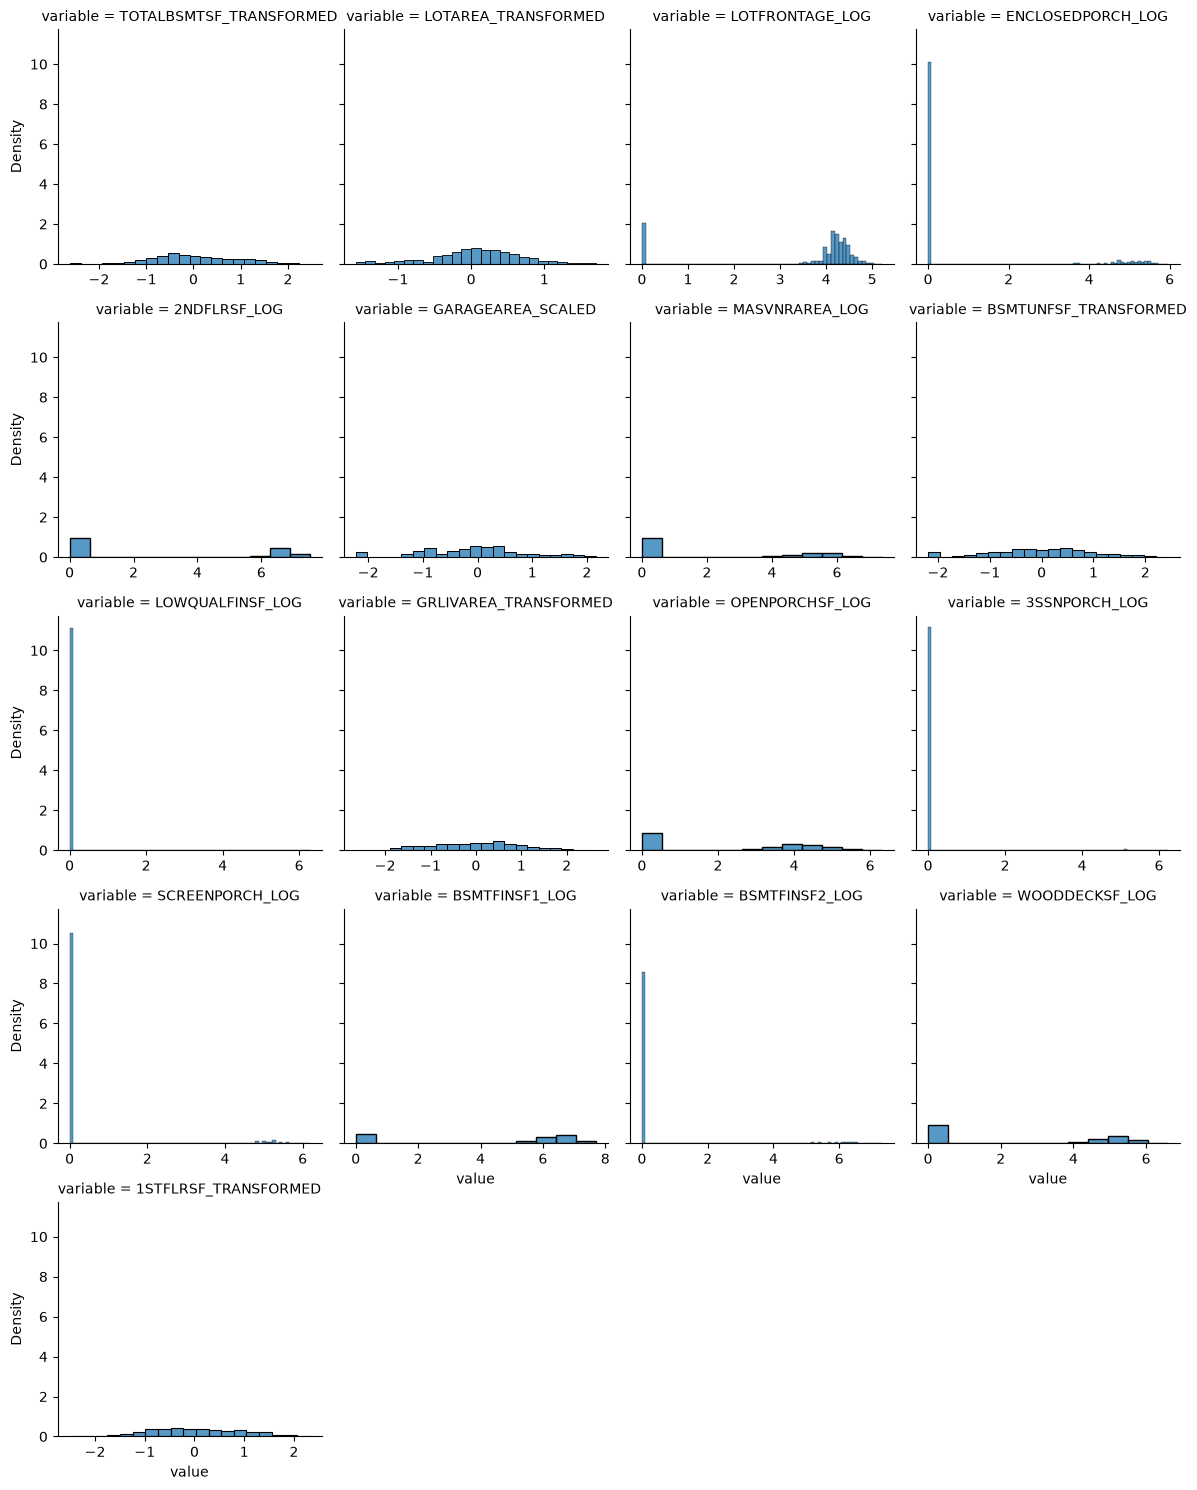

In [1507]:
sns.FacetGrid(
    pd.melt(df_cont, value_vars=cont_cols),
    col="variable",
    col_wrap=4,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value", stat="density")

# Quantitative discrete

In [1508]:
df_disc = df_cont.copy()

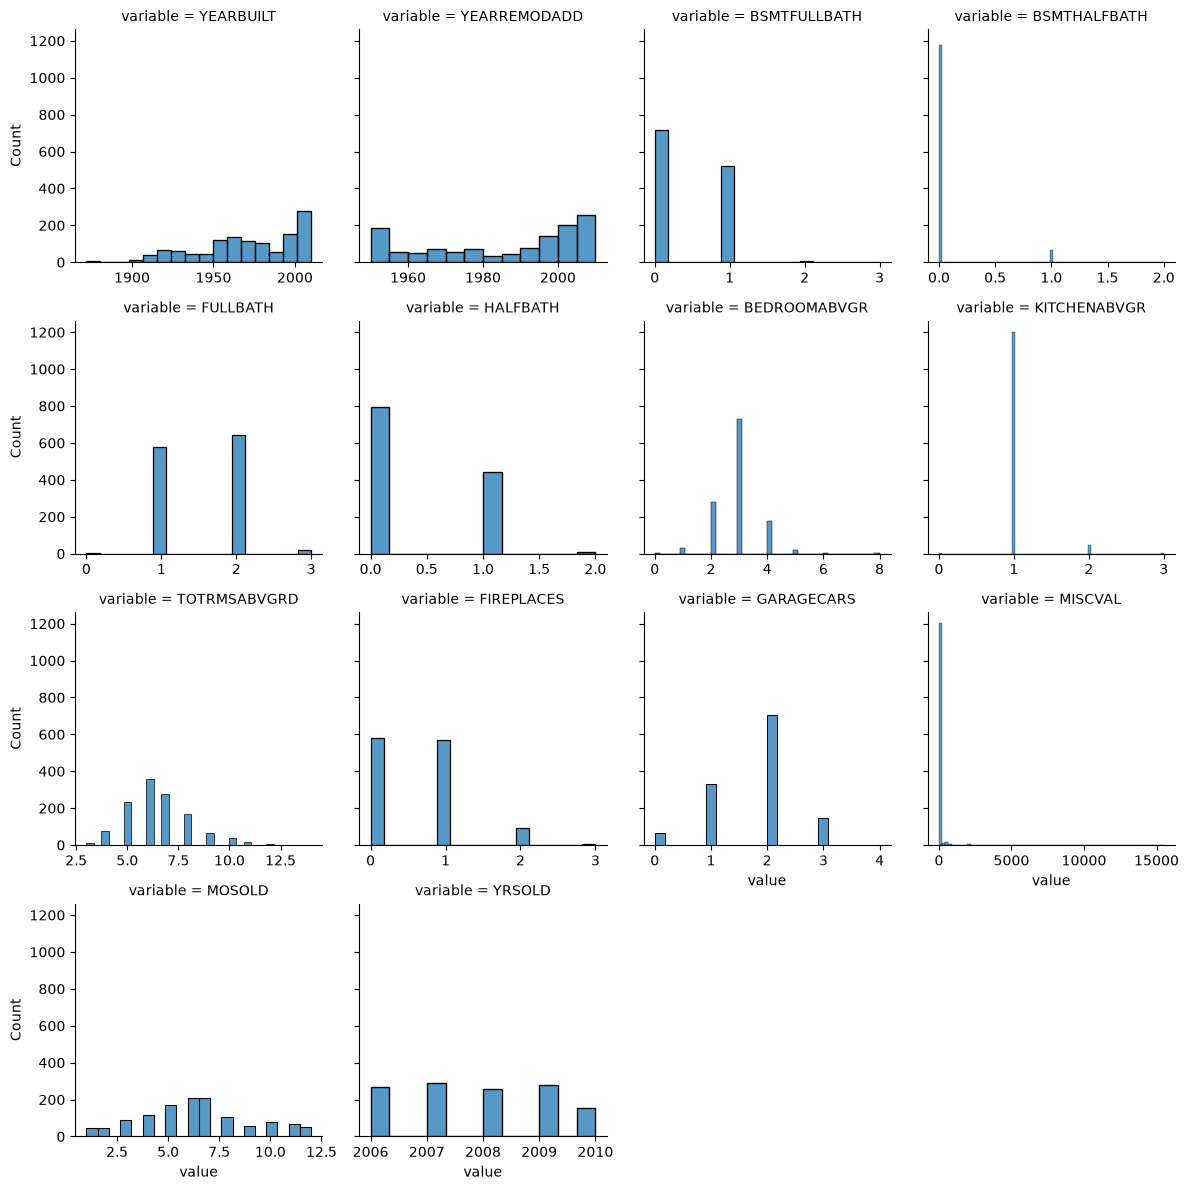

In [1509]:
sns.FacetGrid(
    pd.melt(df_disc, value_vars=disc_cols),
    col="variable",
    col_wrap=4,
    sharex=False,
    sharey=True,
).map(sns.histplot, "value")

In [1510]:
df_disc_zero = zero_pct(df_disc, disc_cols.columns)
df_disc_zero = df_disc_zero[df_disc_zero['ZERO_PCT'] > 0]

df_disc_zero

,ZERO_PCT
MISCVAL,0.963111
BSMTHALFBATH,0.943865
HALFBATH,0.637530
BSMTFULLBATH,0.572574
FIREPLACES,0.466720
GARAGECARS,0.050521
FULLBATH,0.004010
BEDROOMABVGR,0.003208
KITCHENABVGR,0.000802


In [1511]:
drop_cols = []
add_cols = []
zero_flag_map = {}


ZERO_PCT_THRESH = 0.70

zero_flag_map = {
    col: "HAS" + col
    for col in df_disc_zero[df_disc_zero["ZERO_PCT"] > ZERO_PCT_THRESH].index
}

for old_col, new_col in zero_flag_map.items():
    print(old_col, new_col)
    df_disc = df_disc.rename(columns={old_col: new_col})
    df_disc[new_col] = np.where(df_disc[new_col] == 0, 0, 1).astype("bool")
    drop_cols.append(old_col)
    add_cols.append(new_col)


disc_cols = list(set(disc_cols) - set(drop_cols))
bool_cols = list(set(bool_cols).union(set(add_cols)))


MISCVAL HASMISCVAL
BSMTHALFBATH HASBSMTHALFBATH


In [1512]:
df_out = df_disc.copy()

for col in zero_heavy_final_cols:

    non_zero_values = df_disc.loc[df_disc[col] > 0, col]

    Q1 = non_zero_values.quantile(0.25)
    Q3 = non_zero_values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outliers = (df_out[col] == 0) | ((df_out[col] > lower_bound) & (df_out[col] < upper_bound))

pct_removed = round((df_disc.shape[0] - df_out.shape[0]) / df_disc.shape[0] * 100, 2)
print(f"{pct_removed}% removed")
df_disc.shape[0]

0.0% removed


1247

# Qualitative nominal

In [1513]:
df_nom = df_disc.copy()

In [1514]:
df_nom['SALEPRICE']

0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1407    175000.0
1408    210000.0
1409    266500.0
1410    142125.0
1411    147500.0
Name: SALEPRICE, Length: 1247, dtype: float64

In [1515]:
encoder = TargetEncoder(cols=nom_cols, smoothing=5.0)
df_nom[nom_cols] = encoder.fit_transform(df_nom[nom_cols], df_nom['SALEPRICE'])


# Prepare model dataframe

In [1516]:
# Every variable below was transformed earlier in the notebook (power/log
# transform, scaling, or boolean zero-flag). Drop the untransformed originals
# so df_model only keeps the treated versions. SALEPRICE is included since
# SALEPRICE_TRANSFORMED is the modeling target. UTILITIES is included since
# it was flagged for removal during ordinal encoding but never dropped.

df_model = df_nom.copy()

original_to_drop = [
    "LOTAREA", "TOTALBSMTSF", "GRLIVAREA", "1STFLRSF",
    "LOWQUALFINSF", "OPENPORCHSF", "MASVNRAREA", "BSMTFINSF1",
    "BSMTFINSF2", "WOODDECKSF", "ENCLOSEDPORCH", "3SSNPORCH",
    "SCREENPORCH", "2NDFLRSF", "BSMTUNFSF", "GARAGEAREA",
    "LOTFRONTAGE", "SALEPRICE", "UTILITIES",
]

df_model = df_model.drop(columns=original_to_drop)
df_model.head()

,ID,MSSUBCLASS,MSZONING,STREET,ALLEY,HASREGULARLOTSHAPE,LANDCONTOUR,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINTYPE2,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,BSMTFULLBATH,HASBSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEFINISH,GARAGECARS,GARAGEQUAL,GARAGECOND,HASPAVEDDRIVE,HASFENCE,MISCFEATURE,HASMISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,HASGARAGE,HASPOOL,TOTALBSMTSF_TRANSFORMED,GRLIVAREA_TRANSFORMED,1STFLRSF_TRANSFORMED,LOTAREA_TRANSFORMED,HASLOWQUALFINSF,LOWQUALFINSF_LOG,HASOPENPORCHSF,OPENPORCHSF_LOG,HASMASVNRAREA,MASVNRAREA_LOG,HASBSMTFINSF1,BSMTFINSF1_LOG,HASBSMTFINSF2,BSMTFINSF2_LOG,HASWOODDECKSF,WOODDECKSF_LOG,HASENCLOSEDPORCH,ENCLOSEDPORCH_LOG,HAS3SSNPORCH,3SSNPORCH_LOG,HASSCREENPORCH,SCREENPORCH_LOG,HAS2NDFLRSF,2NDFLRSF_LOG,BSMTUNFSF_TRANSFORMED,GARAGEAREA_SCALED,LOTFRONTAGE_LOG,HASLOTFRONTAGE,SALEPRICE_TRANSFORMED
0,1,231819.385185,187435.8125,180416.226688,182591.452846,True,180044.542403,178537.219209,1,196193.850340,184579.037313,180571.153036,181605.523339,214824.500000,2,2,2003,2003,173627.915984,180117.659109,212958.752759,212977.809843,204107.639257,3,2,222558.701465,3,2,1,3,1,181127.859477,3,184551.070698,3,1,False,2,1,3,1,3,8,2,0,0,199379.526728,2,2,2,2,True,False,181295.276063,False,2,2008,173126.719557,175227.222980,True,False,-0.502024,0.526899,-0.807149,-0.139379,False,0.0,True,4.127134,True,5.283204,True,6.561031,False,0.0,False,0.000000,False,0.000000,False,0.0,False,0.0,True,6.751101,-0.986479,0.341377,4.189655,True,0.554081
1,2,181940.885010,187435.8125,180416.226688,182591.452846,True,180044.542403,179753.797163,1,185448.065284,141746.446258,180571.153036,181605.523339,174633.911392,2,3,1976,1976,173627.915984,180117.659109,147464.424731,147852.127778,156267.590120,2,2,150847.716846,3,2,2,3,1,181127.859477,3,184551.070698,3,0,True,2,0,3,1,2,6,2,1,2,199379.526728,2,2,2,2,True,False,181295.276063,False,5,2007,173126.719557,175227.222980,True,False,0.587676,-0.388267,0.438661,0.105266,False,0.0,False,0.000000,False,0.000000,True,6.886532,False,0.0,True,5.700444,False,0.000000,False,0.0,False,0.0,False,0.000000,-0.514241,-0.071106,4.394449,True,0.206022
2,3,231819.385185,187435.8125,180416.226688,182591.452846,False,180044.542403,178537.219209,1,196193.850340,184579.037313,180571.153036,181605.523339,214824.500000,2,2,2001,2002,173627.915984,180117.659109,212958.752759,212977.809843,204107.639257,3,2,222558.701465,3,2,1,3,1,181127.859477,3,184551.070698,3,1,False,2,1,3,1,3,6,2,1,2,199379.526728,2,2,2,2,True,False,181295.276063,False,9,2008,173126.719557,175227.222980,True,False,-0.304801,0.657048,-0.570519,0.410804,False,0.0,True,3.761200,True,5.093750,True,6.188264,False,0.0,False,0.000000,False,0.000000,False,0.0,False,0.0,True,6.765039,-0.109676,0.622616,4.234107,True,0.726788
3,4,165857.469931,187435.8125,180416.226688,182591.452846,False,180044.542403,176850.279167,1,205126.548977,184579.037313,180571.153036,181605.523339,214824.500000,2,2,1915,1970,173627.915984,180117.659109,142952.729730,153294.715684,156267.590120,2,2,130336.644450,2,3,1,3,1,181127.859477,3,184551.070698,3,1,False,1,0,3,1,3,7,2,1,3,134124.122257,1,3,2,2,True,False,181295.276063,False,2,2006,173126.719557,140821.048186,True,False,-0.836425,0.539135,-0.428600,0.095234,False,0.0,True,3.583519,False,0.000000,True,5.379897,False,0.0,False,0.000000,True,5.609472,False,0.0,False,0.0,True,6.629363,0.133421,0.781985,4.110874,True,-0.457522
4,5,231819.385185,187435.8125,180416.226688,182591.452846,False,180044.542403,179753.797163,1,284152.113919,184579.037313,180571.153036,181605.523339,214824.500000,3,2,2000,2000,173627.915984,180117.659109,212958.752759,212977.809843,204107.639257,3,2,222558.701465,3,2,1,3,1,181127.859477,3,184551.07069

In [1517]:
df_model_corr = df_model.corr()
df_model_corr = df_model_corr['SALEPRICE_TRANSFORMED'].abs()
df_model_corr = pd.DataFrame(df_model_corr).sort_values(by=['SALEPRICE_TRANSFORMED'], ascending=False)

corr_mask = (df_model_corr['SALEPRICE_TRANSFORMED'] > 0.45)
df_model_corr = df_model_corr[corr_mask]
df_model = df_model[df_model_corr.index]

df_model_corr = df_model.corr()
df_model_corr['SALEPRICE_TRANSFORMED']

SALEPRICE_TRANSFORMED      1.000000
NEIGHBORHOOD               0.727813
GRLIVAREA_TRANSFORMED      0.703429
OVERALLQUAL                0.672363
GARAGECARS                 0.671316
EXTERQUAL                  0.652364
GARAGEAREA_SCALED          0.639399
YEARBUILT                  0.636697
FULLBATH                   0.621874
KITCHENQUAL                0.621284
GARAGEFINISH               0.608152
BSMTQUAL                   0.604960
YEARREMODADD               0.585422
1STFLRSF_TRANSFORMED       0.574716
TOTALBSMTSF_TRANSFORMED    0.573583
GARAGETYPE                 0.572887
MSSUBCLASS                 0.563470
FOUNDATION                 0.554683
TOTRMSABVGRD               0.510119
FIREPLACEQU                0.507811
EXTERIOR1ST                0.481332
EXTERIOR2ND                0.472260
MASVNRTYPE                 0.471044
FIREPLACES                 0.458281
OPENPORCHSF_LOG            0.451920
Name: SALEPRICE_TRANSFORMED, dtype: float64

In [1518]:
df_model_vif = df_model.copy()
target = df_model['SALEPRICE_TRANSFORMED']
df_model_vif = df_model_vif.drop(columns=['SALEPRICE_TRANSFORMED', 'EXTERIOR2ND', 'GARAGECARS', 'FIREPLACEQU', 'GRLIVAREA_TRANSFORMED', 'YEARBUILT'])

In [1521]:
X = df_model_vif
X = add_constant(X)  

vif_data = pd.DataFrame()
vif_data['VARIAVEL'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by=['VIF'], ascending=False).reset_index(drop=True)
vif_data = vif_data[vif_data['VARIAVEL'] != 'const']

vif_data = vif_data.set_index(['VARIAVEL'], drop=True)

vif_data

,VIF
VARIAVEL,
1STFLRSF_TRANSFORMED,4.859370
TOTALBSMTSF_TRANSFORMED,4.496325
NEIGHBORHOOD,2.898048
EXTERQUAL,2.821648
BSMTQUAL,2.577612
KITCHENQUAL,2.409365
FOUNDATION,2.394816
GARAGEFINISH,2.281200
FULLBATH,2.248757


In [1520]:
df_model = df_model[vif_data.index]
df_model['SALEPRICE_TRANSFORMED'] = target

df_model.head()

,1STFLRSF_TRANSFORMED,TOTALBSMTSF_TRANSFORMED,NEIGHBORHOOD,EXTERQUAL,BSMTQUAL,KITCHENQUAL,FOUNDATION,GARAGEFINISH,FULLBATH,GARAGETYPE,MSSUBCLASS,YEARREMODADD,OVERALLQUAL,GARAGEAREA_SCALED,TOTRMSABVGRD,EXTERIOR1ST,MASVNRTYPE,OPENPORCHSF_LOG,FIREPLACES,SALEPRICE_TRANSFORMED
0,-0.807149,-0.502024,196193.850340,3,3,3,222558.701465,2,2,199379.526728,231819.385185,2003,2,0.341377,8,212958.752759,204107.639257,4.127134,0,0.554081
1,0.438661,0.587676,185448.065284,2,3,2,150847.716846,2,2,199379.526728,181940.885010,1976,2,-0.071106,6,147464.424731,156267.590120,0.000000,1,0.206022
2,-0.570519,-0.304801,196193.850340,3,3,3,222558.701465,2,2,199379.526728,231819.385185,2002,2,0.622616,6,212958.752759,204107.639257,3.761200,1,0.726788
3,-0.428600,-0.836425,205126.548977,2,2,3,130336.644450,1,1,134124.122257,165857.469931,1970,2,0.781985,7,142952.729730,156267.590120,3.583519,1,-0.457522
4,0.132841,0.308044,284152.113919,3,3,3,222558.701465,2,2,199379.526728,231819.385185,2000,3,1.691323,9,212958.752759,204107.639257,4.442651,1,1.003039
